# [스스로 문제해결]
# Water Possibility(음수) 가능 여부를 판단하기
- 데이터 분석(EDA)
- 결측 데이터 처리
- 피처 엔지니어링
- 머신러닝, 모델 평가, 테스트
- 사용 학습기 : KNN, xgboost ML 모델을 만들고 성능 비교하기
- GridSearchCV : 최적의 하이퍼 파라미터를 찾을 때 사용함

In [1]:
# 경고 메시지 숨기기 + matplotlib 기본 설정(폰트/글자크기/그림크기/마이너스 기호 깨짐 방지)
# warning 무시
import warnings
warnings.filterwarnings('ignore')

import matplotlib.pylab as plt
# '-' 깨짐 해결 모듈
import matplotlib as mpl

plt.rcParams["font.family"] = "Malgun Gothic"  # For Windows
plt.rcParams["font.size"] = 12
plt.rcParams["figure.figsize"] = (8,4)
print(plt.rcParams["font.family"])

# 마이너스 깨짐 해결
mpl.rcParams["axes.unicode_minus"] = False

['Malgun Gothic']


In [2]:
# 분석에 사용할 기본 라이브러리 import
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# 실행 환경(OS)에 맞춰 한글 폰트 설정
# 한글 폰트 설정
import platform

from matplotlib import rc
plt.rcParams['axes.unicode_minus'] = False

if platform.system() == 'Linux':
    rc('font', family = 'NanumGothic')  # 또는 '나눔고딕'
    print('Linux system... font set to NanumGothic')
elif platform.system() == 'Windows':
    rc('font', family = 'Malgun Gothic')   # 또는 '맑은 고딕'
    print('Windows system... font set to Malgun Gothic')
else:
    print('Unknown system... sorry~~~~')

Linux system... font set to NanumGothic


데이터 출처 : [https://www.kaggle.com/datasets/adityakadiwal/water-potability](https://www.kaggle.com/datasets/adityakadiwal/water-potability)

### 데이터 설명
1. ph: pH 1. 물(0~14).량
2. Hardness비누를 침전시키는 물의 용량(mg/L)L.
3. Solid총 용해 고형물(ppm)pm.
4. Chloramin클로라민의 양(ppm).ppm.
5. Sulfmg/L 단위로 용해된 황산염의 양.mg/L.
6. Conducti물의 전기 전도도(단위: μS/cm).μS/cm.
7. Organic_c유기 탄소의 양(ppm).in ppm.
8. Trihalomeμg/L 단위의 트리할로메탄 양.in μg/L.
9. Tu NTU 단위로 물의 발광 특성을 측정함.r in NTU.
10. Po물이 인간이 섭취하기에 안전한지 여부를 나타냄
    - 마실 수 있는 -> 1
    - 마실 수 없는 -0potable -> 0

사용할 데이터는 사람이 마실 수 잇는 물인지 아닌지를 판단하는 데이터 입니다.
- 독립변수(X) : ph ~ Turbidity
- 종속변수(y) : potability

## 1. Data Load

In [4]:
# 물 수질 데이터 CSV 파일 로드
water_df = pd.read_csv('datas_ml/water_potability.csv')

In [5]:
# 상위 5개 행을 출력해 데이터 형태 확인
water_df.head()

,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
0,NaN,204.890455,20791.318981,7.300212,368.516441,564.308654,10.379783,86.990970,2.963135,0
1,3.716080,129.422921,18630.057858,6.635246,NaN,592.885359,15.180013,56.329076,4.500656,0
2,8.099124,224.236259,19909.541732,9.275884,NaN,418.606213,16.868637,66.420093,3.055934,0
3,8.316766,214.373394,22018.417441,8.059332,356.886136,363.266516,18.436524,100.341674,4.628771,0
4,9.092223,181.101509,17978.986339,6.546600,310.135738,398.410813,11.558279,31.997993,4.075075,0


## 2. 데이터 정보, 기술통계확인

In [8]:
# 행 수, 컬럼별 결측치 수, 데이터 타입 등 전체 구조 확인
water_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3276 entries, 0 to 3275
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ph               2785 non-null   float64
 1   Hardness         3276 non-null   float64
 2   Solids           3276 non-null   float64
 3   Chloramines      3276 non-null   float64
 4   Sulfate          2495 non-null   float64
 5   Conductivity     3276 non-null   float64
 6   Organic_carbon   3276 non-null   float64
 7   Trihalomethanes  3114 non-null   float64
 8   Turbidity        3276 non-null   float64
 9   Potability       3276 non-null   int64  
dtypes: float64(9), int64(1)
memory usage: 256.1 KB


- 기술통계 확인하기

In [9]:
# 수치형 컬럼들의 기술통계(평균/표준편차/사분위 등) 확인
water_df.describe()

,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
count,2785.000000,3276.000000,3276.000000,3276.000000,2495.000000,3276.000000,3276.000000,3114.000000,3276.000000,3276.000000
mean,7.080795,196.369496,22014.092526,7.122277,333.775777,426.205111,14.284970,66.396293,3.966786,0.390110
std,1.594320,32.879761,8768.570828,1.583085,41.416840,80.824064,3.308162,16.175008,0.780382,0.487849
min,0.000000,47.432000,320.942611,0.352000,129.000000,181.483754,2.200000,0.738000,1.450000,0.000000
25%,6.093092,176.850538,15666.690297,6.127421,307.699498,365.734414,12.065801,55.844536,3.439711,0.000000
50%,7.036752,196.967627,20927.833607,7.130299,333.073546,421.884968,14.218338,66.622485,3.955028,0.000000
75%,8.062066,216.667456,27332.762127,8.114887,359.950170,481.792304,16.557652,77.337473,4.500320,1.000000
max,14.000000,323.124000,61227.196008,13.127000,481.030642,753.342620,28.300000,124.000000,6.739000,1.000000


## 3. 데이터 시각화

### 모든 컬럼들의 데이터 분포 확인
- seaborn의 pairplot를 활용해 모든 컬럼들간의 데이터 분포 확인하기
- hue='Potability'

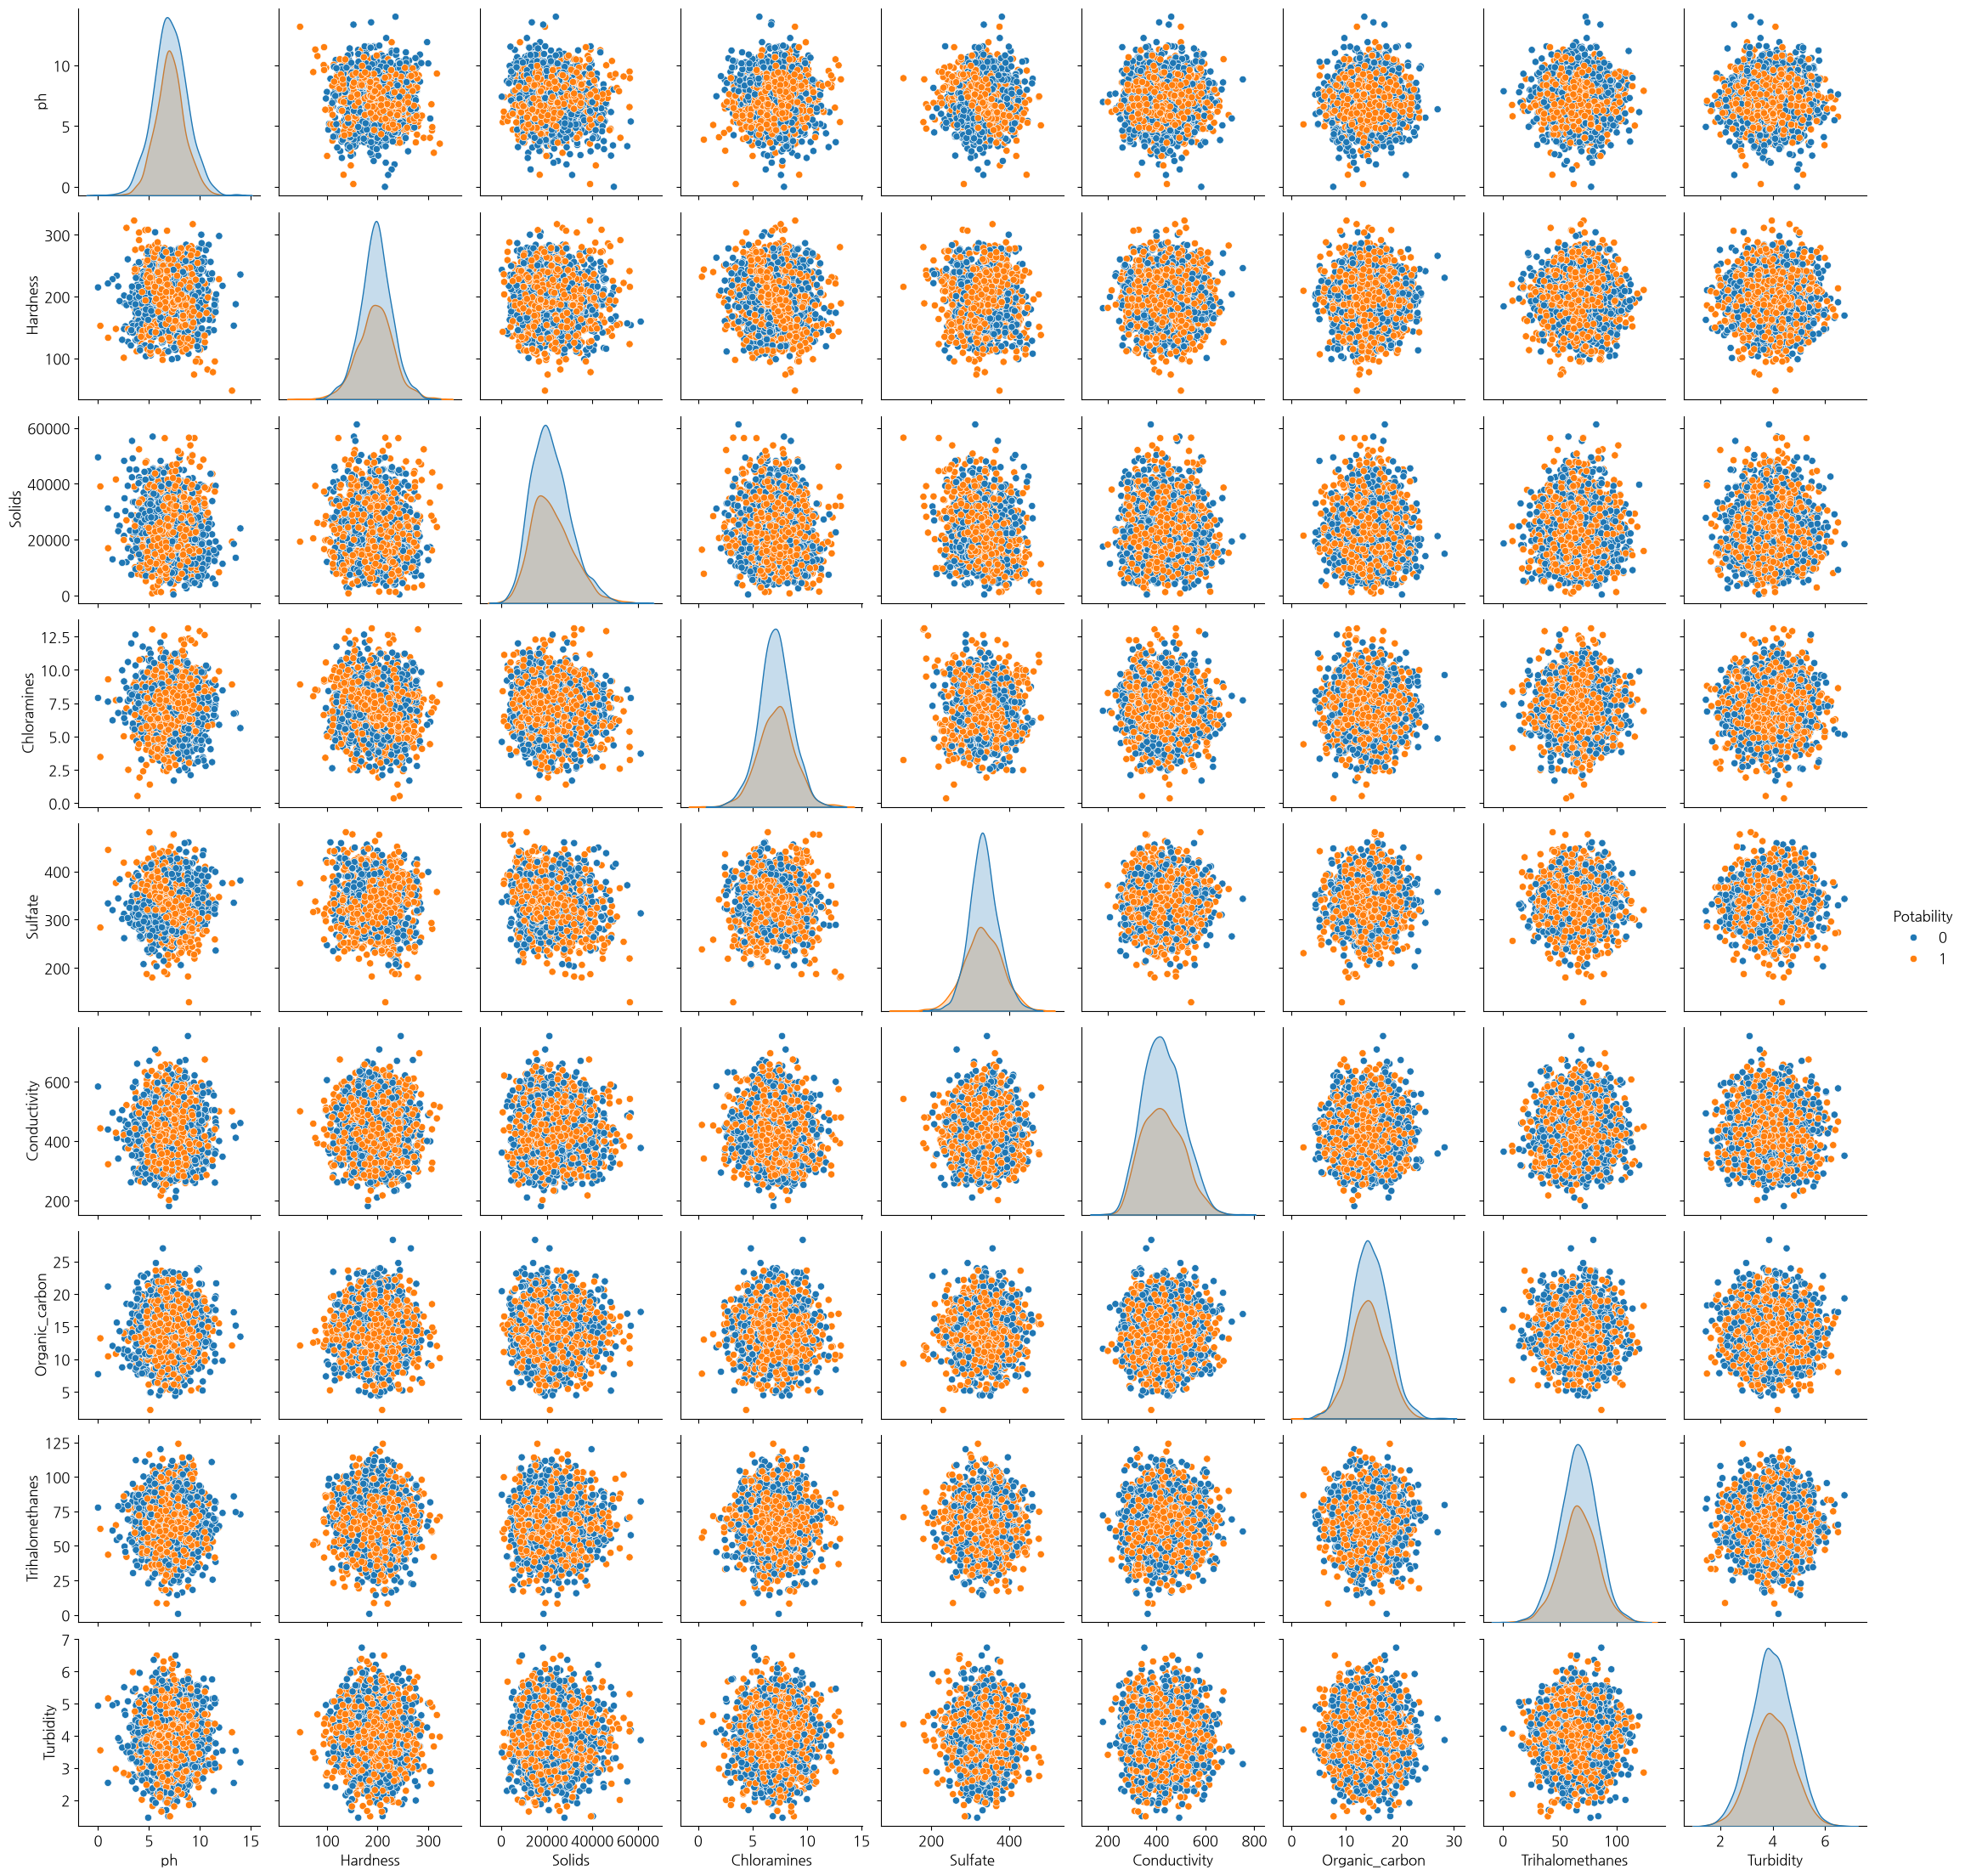

In [10]:
# 모든 피처 쌍의 관계와 분포를 Potability 기준으로 시각화(pairplot)
sns.pairplot(water_df, hue='Potability')
plt.show()

### Potability 컬럼을 제외한 컬럼이름만 리스트로 추출

In [11]:
# 타깃(Potability)을 제외한 독립변수 컬럼 이름만 리스트로 추출
col_names = water_df.columns.drop('Potability').tolist()
col_names

['ph',
 'Hardness',
 'Solids',
 'Chloramines',
 'Sulfate',
 'Conductivity',
 'Organic_carbon',
 'Trihalomethanes',
 'Turbidity']

### 데이터 분포, 관계 시각화
- 각 피처와 Potability와의 관계 확인
- histplot으로 그리기

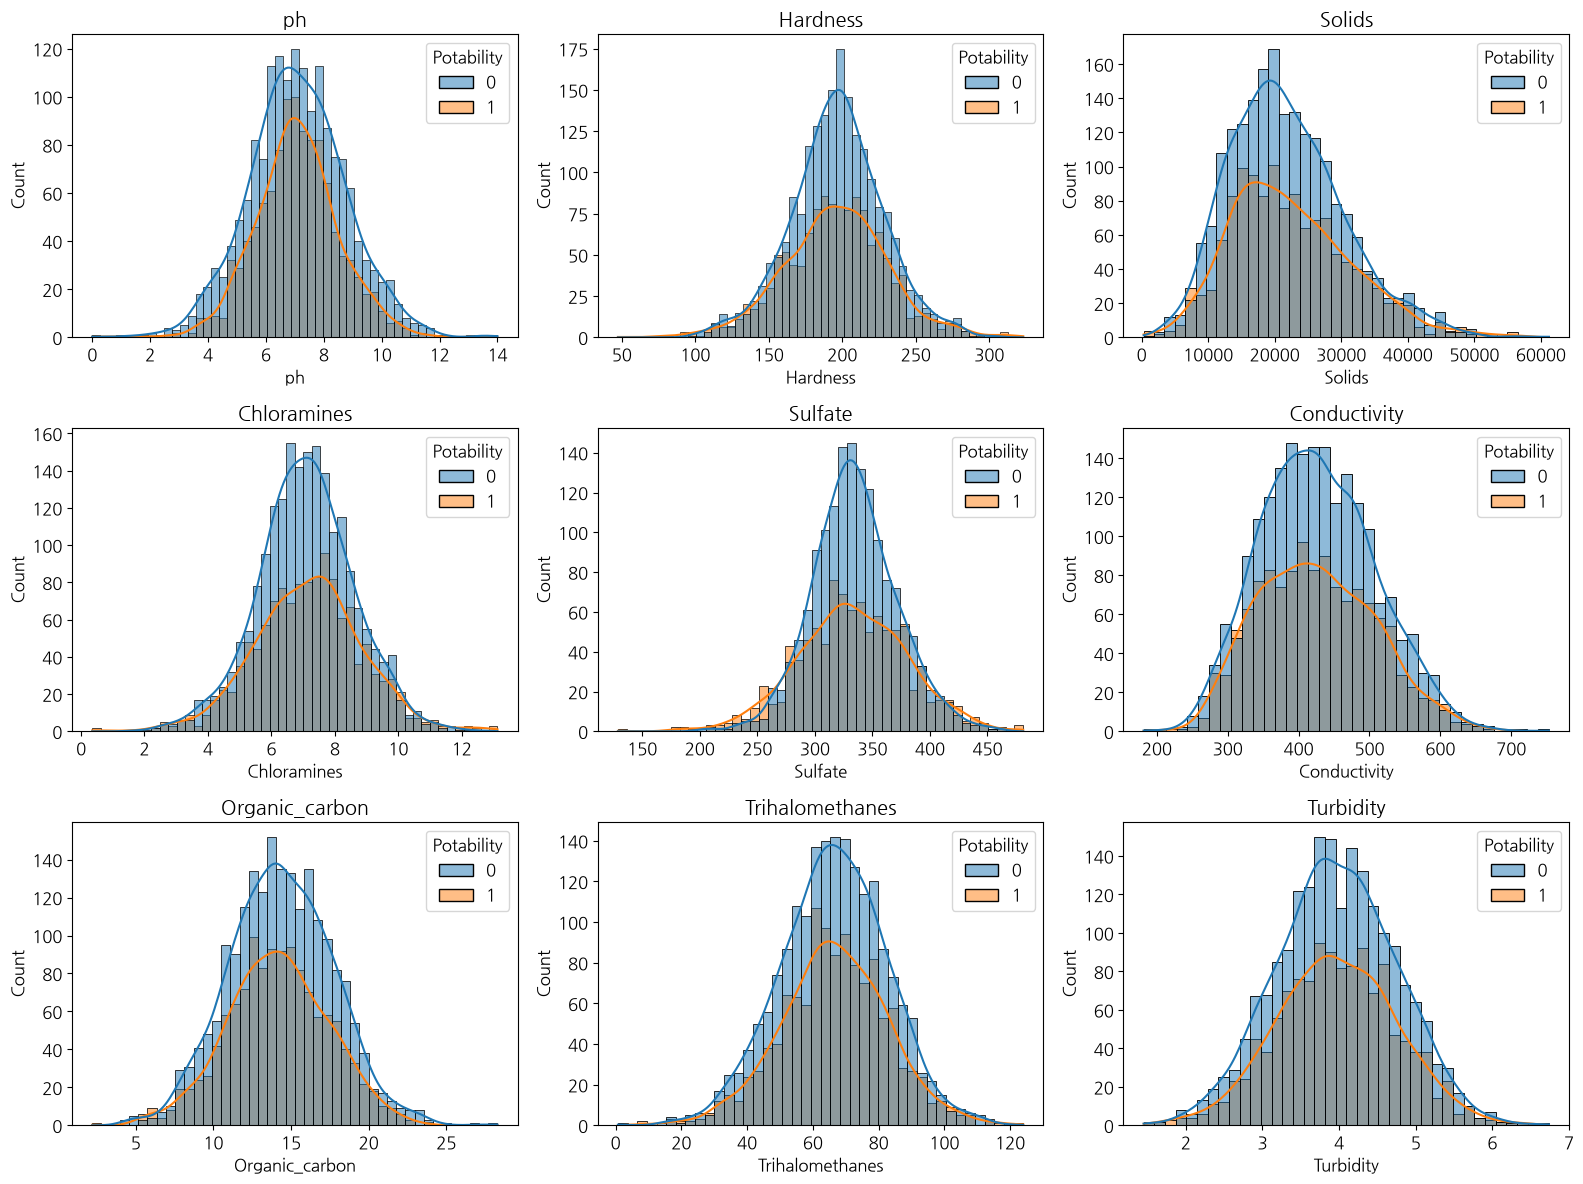

In [12]:
# 각 피처의 분포를 Potability(0/1)별로 히스토그램으로 비교 (3x3 그리드)
nrows, ncols = 3, 3
figure, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(16, 12))

for i, col in enumerate(col_names):
    ax = axes[i // ncols, i % ncols]
    sns.histplot(data=water_df, x=col, hue='Potability', kde=True, ax=ax)
    ax.set_title(col)

plt.tight_layout()
plt.show()


### 범위, 분포, 이상치 시각화

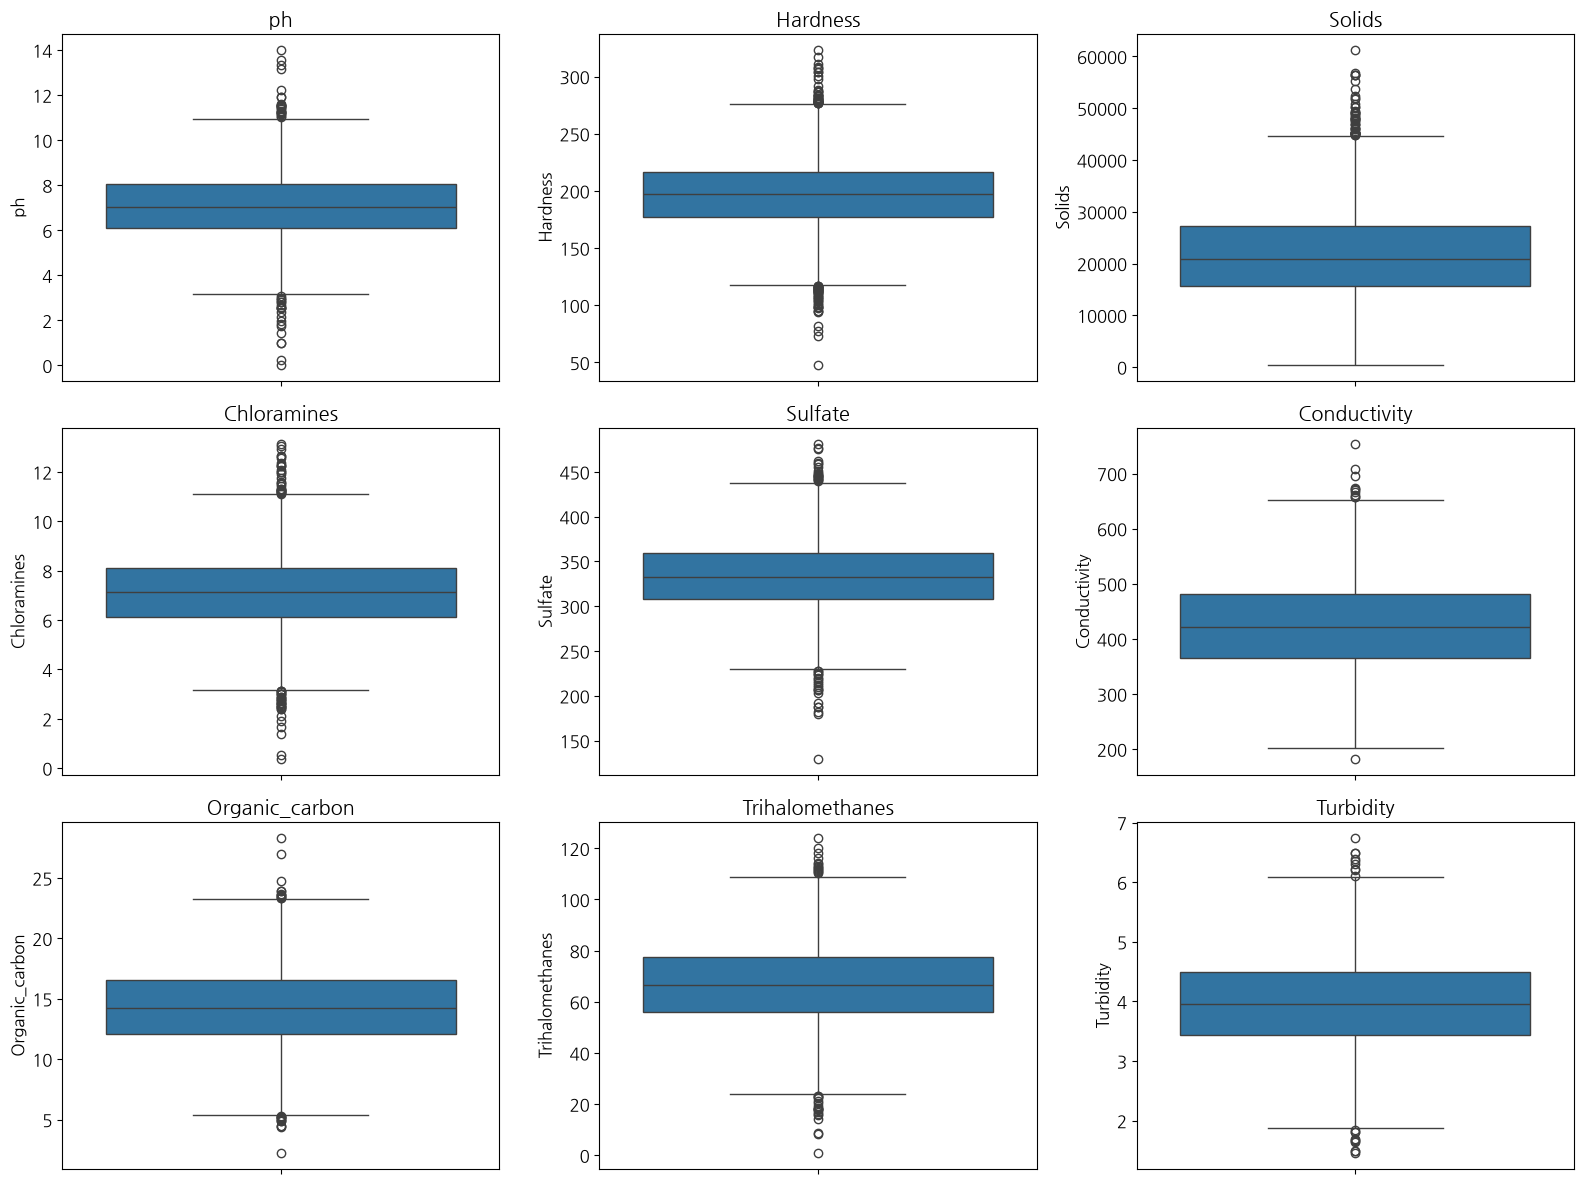

In [15]:
# 각 피처의 범위/분포/이상치를 박스플롯으로 확인 (3x3 그리드)
nrows, ncols = 3, 3
figure, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(16, 12))

for i, col in enumerate(col_names):
    ax = axes[i // ncols, i % ncols]
    sns.boxplot(data=water_df, y=col, ax=ax)
    ax.set_title(col)

plt.tight_layout()
plt.show()


### 각 피처들의 상관계수 시각화

In [17]:
# 피처 간 상관계수 행렬 계산
corr_df = water_df.corr()
corr_df

,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
ph,1.000000,0.082096,-0.089288,-0.034350,0.018203,0.018614,0.043503,0.003354,-0.039057,-0.003556
Hardness,0.082096,1.000000,-0.046899,-0.030054,-0.106923,-0.023915,0.003610,-0.013013,-0.014449,-0.013837
Solids,-0.089288,-0.046899,1.000000,-0.070148,-0.171804,0.013831,0.010242,-0.009143,0.019546,0.033743
Chloramines,-0.034350,-0.030054,-0.070148,1.000000,0.027244,-0.020486,-0.012653,0.017084,0.002363,0.023779
Sulfate,0.018203,-0.106923,-0.171804,0.027244,1.000000,-0.016121,0.030831,-0.030274,-0.011187,-0.023577
Conductivity,0.018614,-0.023915,0.013831,-0.020486,-0.016121,1.000000,0.020966,0.001285,0.005798,-0.008128
Organic_carbon,0.043503,0.003610,0.010242,-0.012653,0.030831,0.020966,1.000000,-0.013274,-0.027308,-0.030001
Trihalomethanes,0.003354,-0.013013,-0.009143,0.017084,-0.030274,0.001285,-0.013274,1.000000,-0.022145,0.007130
Turbidity,-0.039057,-0.014449,0.019546,0.002363,-0.011187,0.005798,-0.027308,-0.022145,1.000000,0.001581
Potability,-0.003556,-0.013837,0.033743,0.023779,-0.023577,-0.008128,-0.030001,0.007130,0.001581,1.000000


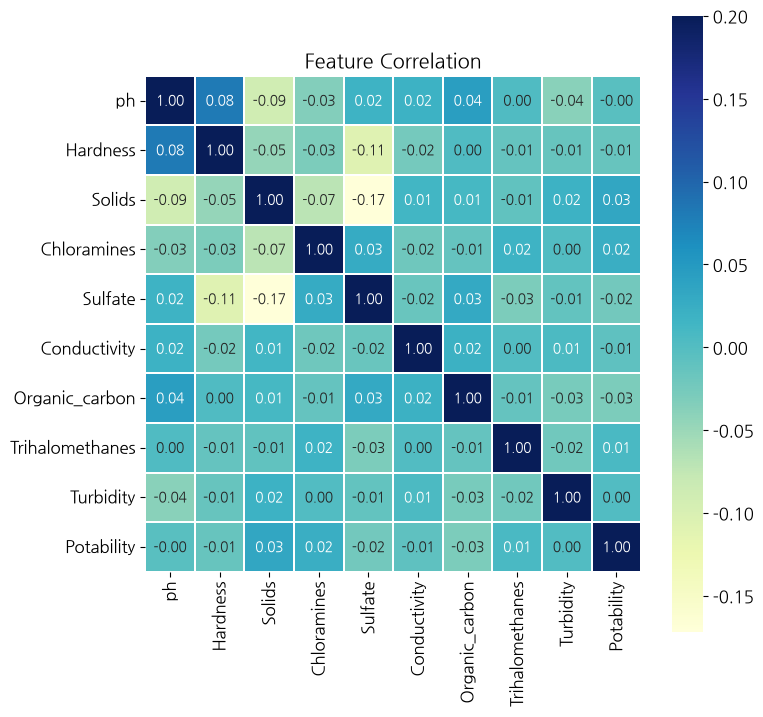

In [18]:
# 상관계수 행렬을 히트맵으로 시각화
# 피처들간의 상관관계 살펴보기
plt.figure(figsize=(8, 8));
sns.heatmap(corr_df,
            vmax=0.2,
            linewidths=0.01,
            square=True,
            annot=True,
            fmt = '.2f', # annot의 출력 소숫점 자리 지정
            annot_kws={"size": 10},  # annot 글자크기
            cmap='YlGnBu');
plt.title('Feature Correlation');

## 4. Data Preprocess

- 각 컬럼별로 결측 데이터의 갯수가 몇개인지 확인하기

In [20]:
# 결측치 처리 전 데이터 구조 재확인
water_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3276 entries, 0 to 3275
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ph               2785 non-null   float64
 1   Hardness         3276 non-null   float64
 2   Solids           3276 non-null   float64
 3   Chloramines      3276 non-null   float64
 4   Sulfate          2495 non-null   float64
 5   Conductivity     3276 non-null   float64
 6   Organic_carbon   3276 non-null   float64
 7   Trihalomethanes  3114 non-null   float64
 8   Turbidity        3276 non-null   float64
 9   Potability       3276 non-null   int64  
dtypes: float64(9), int64(1)
memory usage: 256.1 KB


In [21]:
# 컬럼별 결측치 개수 확인
water_df.isna().sum()

ph                 491
Hardness             0
Solids               0
Chloramines          0
Sulfate            781
Conductivity         0
Organic_carbon       0
Trihalomethanes    162
Turbidity            0
Potability           0
dtype: int64

#### nan이 하나라도 있는 index(행) 삭제

In [22]:
# 결측치가 하나라도 있는 행을 제거한 새 DataFrame 생성 (원본 water_df는 유지)
drop_row = water_df.dropna()

In [23]:
# 결측 제거 후 데이터 크기 확인
drop_row.shape

(2011, 10)

In [24]:
# 원본 데이터 크기와 비교
water_df.shape

(3276, 10)

In [25]:
# 결측 제거 후 데이터 정보 확인 (결측치 0인지 확인)
drop_row.info()

<class 'pandas.DataFrame'>
Index: 2011 entries, 3 to 3271
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ph               2011 non-null   float64
 1   Hardness         2011 non-null   float64
 2   Solids           2011 non-null   float64
 3   Chloramines      2011 non-null   float64
 4   Sulfate          2011 non-null   float64
 5   Conductivity     2011 non-null   float64
 6   Organic_carbon   2011 non-null   float64
 7   Trihalomethanes  2011 non-null   float64
 8   Turbidity        2011 non-null   float64
 9   Potability       2011 non-null   int64  
dtypes: float64(9), int64(1)
memory usage: 172.8 KB


## 5. Data Split

### drop_row 데이터 프레임에서 독립변수 X 와 종속변수 y로 나누기

In [26]:
# 독립변수 X: 타깃을 제외한 모든 피처
X = drop_row[col_names]

In [27]:
# 독립변수 X의 크기 확인
X.shape

(2011, 9)

In [28]:
# 종속변수 y: 예측 대상인 Potability
y = drop_row['Potability']

In [29]:
# 종속변수 y의 크기 확인
y.shape

(2011,)

In [30]:
# X, y 분리 후 원본(drop_row) 정보 재확인
drop_row.info()

<class 'pandas.DataFrame'>
Index: 2011 entries, 3 to 3271
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ph               2011 non-null   float64
 1   Hardness         2011 non-null   float64
 2   Solids           2011 non-null   float64
 3   Chloramines      2011 non-null   float64
 4   Sulfate          2011 non-null   float64
 5   Conductivity     2011 non-null   float64
 6   Organic_carbon   2011 non-null   float64
 7   Trihalomethanes  2011 non-null   float64
 8   Turbidity        2011 non-null   float64
 9   Potability       2011 non-null   int64  
dtypes: float64(9), int64(1)
memory usage: 172.8 KB


## 6. 피처 스케일링
- 데이터의 특성을 파악하여 피처 스케일 방법을 선택하고 독립변수에 적용하기
- 이상치가 많다고 판단하여 RobustScaler 사용

In [31]:
# 이상치가 많아 중앙값/IQR 기반의 RobustScaler로 피처 스케일링
from sklearn.preprocessing import RobustScaler

scaler = RobustScaler()
X_scaled = scaler.fit_transform(X)


In [32]:
# 스케일링 결과 배열의 앞부분 확인
X_scaled[:5]

array([[ 0.65680483,  0.43282692,  0.09379373,  0.46448723,  0.47688378,
        -0.52025154,  0.90251278,  1.58391031,  0.61665097],
       [ 1.05179243, -0.40533748, -0.25542893, -0.30307355, -0.42741347,
        -0.21647915, -0.60622354, -1.61880978,  0.0997875 ],
       [-0.73511455, -0.22366198,  0.67564865,  0.20344828, -0.10742795,
        -1.23592751, -1.29904724, -0.54473938, -1.31477791],
       [ 1.6282047 ,  1.28173434,  0.67573759,  0.1874853 ,  1.1882697 ,
        -1.20840881, -0.11676465,  0.84639096, -1.20903279],
       [ 0.81933308,  0.15542278, -0.62777472, -1.30954823, -0.55944876,
         0.44213393, -0.42952973, -0.17544605,  0.40442813]])

In [33]:
# 스케일링 후 DataFrame 복원에 쓸 컬럼명 보관
x_cols = X.columns
x_cols

Index(['ph', 'Hardness', 'Solids', 'Chloramines', 'Sulfate', 'Conductivity',
       'Organic_carbon', 'Trihalomethanes', 'Turbidity'],
      dtype='str')

In [34]:
# 스케일링된 배열을 컬럼명과 함께 DataFrame으로 복원
X_scaled_df = pd.DataFrame(X_scaled, columns=x_cols)
X_scaled_df.head(3)

,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity
0,0.656805,0.432827,0.093794,0.464487,0.476884,-0.520252,0.902513,1.583910,0.616651
1,1.051792,-0.405337,-0.255429,-0.303074,-0.427413,-0.216479,-0.606224,-1.618810,0.099787
2,-0.735115,-0.223662,0.675649,0.203448,-0.107428,-1.235928,-1.299047,-0.544739,-1.314778


## 7. 데이터를 Train, Test로 나누기

<Axes: xlabel='Potability', ylabel='count'>

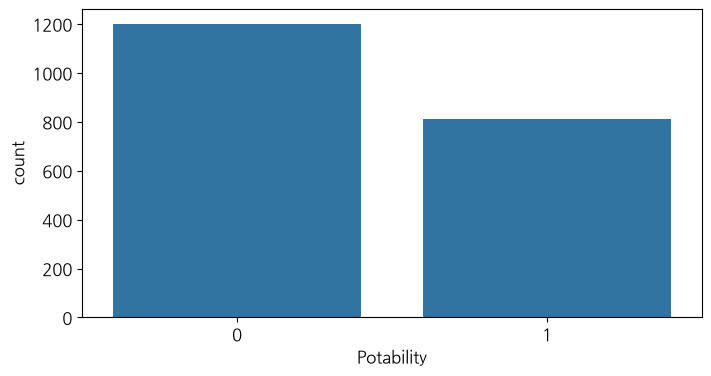

In [35]:
# 타깃 클래스(Potability) 비율 확인 - 불균형 여부 점검
# 'Potability' 컬럼 값 비율 확인
sns.countplot(x=y)

- y 값을 균일하게 분할
- test data size 0.2
- 실행할 때마다 분할이 재현되도록 random_state 2024

In [36]:
# 학습/테스트 분할 (test 20%, stratify=y로 클래스 비율 유지, 재현성 위해 random_state 고정)
from sklearn.model_selection import train_test_split

train_X, test_X, train_y, test_y = train_test_split(X_scaled, y, test_size=0.2, stratify=y,  random_state=2024)


In [37]:
# 학습셋 크기 확인
train_X.shape, train_y.shape

((1608, 9), (1608,))

In [38]:
# 테스트셋 크기 확인
test_X.shape, test_y.shape

((403, 9), (403,))

## 8. KNN ML 모델 만들기 및 평가

In [39]:
# KNN 분류기 import
from sklearn.neighbors import KNeighborsClassifier


### GridSearchCV활용 Best Hyper Parameter 찾기
다음의 파라미터에 대해서 KNN 모델의 베스트 파라미터를 찾아보세요.

- n_neighbors : [2, 4, 6, 8, 10],
- p : [1, 2]
- cv : 3

In [40]:
# 하이퍼파라미터 탐색용 GridSearchCV import
from sklearn.model_selection import GridSearchCV

In [41]:
# KNN 하이퍼파라미터 후보 그리드 정의 (n_neighbors, p)
params = {
    'n_neighbors' : [2, 4, 6, 8, 10],
    'p' : [1, 2]
}

In [42]:
# 정의한 파라미터 그리드 확인
params

{'n_neighbors': [2, 4, 6, 8, 10], 'p': [1, 2]}

In [ ]:
# KNN + 3-fold 교차검증으로 최적 파라미터를 탐색하는 GridSearchCV 객체 생성
# 객체 생성
grid_cv = GridSearchCV(
    KNeighborsClassifier(),
    param_grid=params,
    cv=3,
    scoring='accuracy',
    n_jobs=-1
)

In [ ]:
# 학습셋으로 그리드 서치(교차검증) 수행
# 학습
grid_cv.fit(train_X, train_y)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",KNeighborsClassifier()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'n_neighbors': [2, 4, ...], 'p': [1, 2]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose: int, default=0Controls the verbosity of information printed during fittin

#### 모델 평가

In [46]:
# 교차검증에서 얻은 최고 정확도 출력
print(f"Best score of paramter search is: {grid_cv.best_score_:.4f}")

Best score of paramter search is: 0.6387


In [47]:
# 최고 성능을 낸 하이퍼파라미터 조합 확인
grid_cv.best_params_

{'n_neighbors': 10, 'p': 2}

In [48]:
# 최적 하이퍼파라미터를 항목별로 출력
print("Best parameter of best score is")
print(f"\t n_neighbors: {grid_cv.best_params_['n_neighbors']}")
print(f"\t p: {grid_cv.best_params_['p']}")

Best parameter of best score is
	 n_neighbors: 10
	 p: 2


#### 예측 및 평가

In [49]:
# 최적 KNN 모델로 테스트셋 예측
test_pred = grid_cv.predict(test_X)

In [51]:
# 테스트셋 정확도 평가
from sklearn.metrics import accuracy_score
test_acc = accuracy_score(test_y, test_pred)
print(f"test accuracy is {test_acc:.4f}")

test accuracy is 0.6303


In [52]:
# 정밀도/재현율/F1-score 등 분류 성능 상세 리포트 출력
# 분류 성능 레포트
from sklearn.metrics import classification_report

# y_test: 실제 라벨, y_pred: 모델 예측 라벨
print("정확도:", accuracy_score(test_y, test_pred))
print("\n[정밀도, 재현율, F1-score 요약 보고서]")
print(classification_report(test_y, test_pred))

정확도: 0.630272952853598

[정밀도, 재현율, F1-score 요약 보고서]
              precision    recall  f1-score   support

           0       0.64      0.89      0.74       240
           1       0.61      0.25      0.35       163

    accuracy                           0.63       403
   macro avg       0.62      0.57      0.55       403
weighted avg       0.62      0.63      0.58       403



## 9. xgboost 모델 만들기 및 평가

In [62]:
# xgboost 분류기 생성 후 학습셋으로 학습
from xgboost import XGBClassifier

xgb_clf = XGBClassifier(random_state=2024)

xgb_clf.fit(train_X, train_y)

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",None
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [63]:
# 학습/테스트 정확도를 비교해 과적합 여부 확인
train_pred = xgb_clf.predict(train_X)
test_pred = xgb_clf.predict(test_X)

train_acc = accuracy_score(train_y, train_pred)
test_acc = accuracy_score(test_y, test_pred)

print(f"train accuracy is {train_acc:.4f}")
print(f"test accuracy is {test_acc:.4f}")

train accuracy is 1.0000
test accuracy is 0.6700


In [64]:
# xgboost 모델의 분류 성능 리포트 출력
# classification_report() 결과 출력
print(classification_report(test_y, test_pred))

              precision    recall  f1-score   support

           0       0.69      0.80      0.74       240
           1       0.62      0.48      0.54       163

    accuracy                           0.67       403
   macro avg       0.66      0.64      0.64       403
weighted avg       0.66      0.67      0.66       403



## 10. ML 모델의 feature importance 시각화

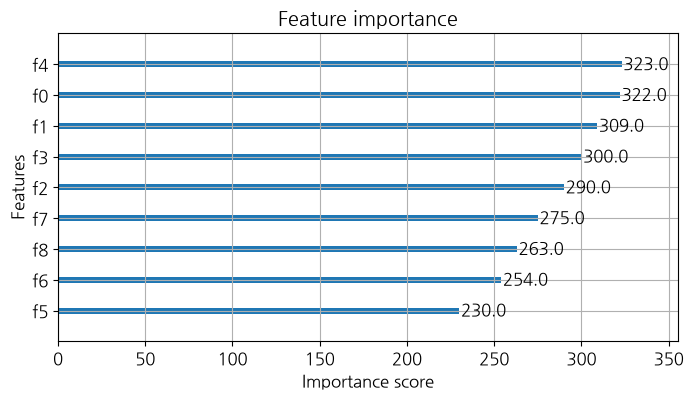

In [66]:
# xgboost의 피처 중요도(feature importance) 시각화
#xgboost의 강력한 기능 Feature Importance 확인
from xgboost import plot_importance
from matplotlib import pyplot

plot_importance(xgb_clf)
pyplot.show()

## 11. 최적의 하이퍼 파라미터 찾기
- xgboost 모델이 과적합인 것 같다.
- xgboost 활용해 베스트 하이퍼 파리터 찾기
- GridSearchCV를 활용해 베스트 하이퍼 파라미터를 찾는 과정을 기술하고 모델을 평가해 보세요.

In [74]:
# 하이퍼파라미터 튜닝용 xgboost 객체 재생성
from xgboost import XGBClassifier
xgb_clf = XGBClassifier(random_state=2024)

In [75]:
# 과적합 완화를 위한 xgboost 하이퍼파라미터 후보 그리드 정의
 # xgboost의 best param을 찾기위한 grid map 정의
xgb_params = {
    'n_estimators': [100, 200],
    'max_depth': [3, 4, 5],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.7, 0.9],
    'colsample_bytree': [0.7, 0.9],
    'reg_lambda': [1, 5, 10],
}

In [76]:
# xgboost + 3-fold 교차검증 GridSearchCV 객체 생성
from sklearn.model_selection import GridSearchCV

xgb_grid = GridSearchCV(
    estimator=xgb_clf,
    param_grid=xgb_params,
    cv=3,
    scoring='accuracy',
    n_jobs=-1,
)


In [77]:
# 학습셋으로 그리드 서치(교차검증) 수행
# GridSearchCV 학습 수행
xgb_grid.fit(train_X, train_y)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","XGBClassifier...ree=None, ...)"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'colsample_bytree': [0.7, 0.9], 'learning_rate': [0.01, 0.05, ...], 'max_depth': [3, 4, ...], 'n_estimators': [100, 200], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",T

In [78]:
# 최적 추정기 / 최고 교차검증 점수 / 최적 파라미터 출력
print(f"Best estimator : {xgb_grid.best_estimator_}")
print(f"Best score of parameter search is: {xgb_grid.best_score_:.10f}")
print(f"Best param : {xgb_grid.best_params_}")


Best estimator : XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.9, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.05, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=4,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=100,
              n_jobs=None, num_parallel_tree=None, ...)
Best score of parameter search is: 0.6691542289
Best param : {'colsample_bytree': 0.9, 'learning_rate': 0.05, 'max_depth': 4, 'n_estimators': 100, 'reg_lambda': 10, 'subsample': 0.7}


In [79]:
# 그리드 서치로 찾은 최적 xgboost 모델 추출
best_xgb = xgb_grid.best_estimator_

In [80]:
# 최적 모델로 학습/테스트셋 예측
train_pred = best_xgb.predict(train_X)
test_pred = best_xgb.predict(test_X)

In [81]:
# 튜닝된 모델의 정확도와 분류 리포트로 과적합 개선 여부 확인
train_acc = accuracy_score(train_y, train_pred)
test_acc = accuracy_score(test_y, test_pred)

print(f"train accuracy is {train_acc:.4f}")
print(f"test accuracy is {test_acc:.4f}")
print()
print(classification_report(test_y, test_pred))

train accuracy is 0.7655
test accuracy is 0.6799

              precision    recall  f1-score   support

           0       0.67      0.90      0.77       240
           1       0.71      0.36      0.47       163

    accuracy                           0.68       403
   macro avg       0.69      0.63      0.62       403
weighted avg       0.69      0.68      0.65       403

